# 1 — Top-N distributions

Four panels on the filtered rules dataset: top group categories, criterion
distribution, top resource categories, resource type (8 meta-categories),
and top rules.

**Source**: `data/processed_data/rules_final_dataset_130works_april_2026.tsv`
(gold-filtered, 1 011 rules).

*Follows `notebook_rule.md`: load at top, preprocess separately, one figure
per cell with its section header, no figures saved to disk.*

## 1. Setup — imports, style config, paths

In [1]:
import ast
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

# Reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)

DATA = Path('../data/clean/final/rules_final_dataset_130works_april_2026.tsv')

In [2]:
# Science-journal minimal style — defined once, used throughout.
plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'legend.frameon': False,
})

BAR = '#2c3e50'  # neutral dark slate — single bar colour

## 2. Load data

In [3]:
df_raw = pd.read_csv(DATA, sep='\t')
print(f'Loaded {len(df_raw):,} rules from {DATA.name}')
df_raw.head()

Loaded 1,011 rules from rules_final_dataset_130works_april_2026.tsv


,rule_uid,file_id,perseus_author,perseus_title,wikidata_work_id,wikidata_work_label,author_wikidata_id,author_impact_date,year,period,...,group_immutability,immutability_reasoning,rule_contemporarity,contemporarity_reasoning,opinion_vs_fact,opinion_vs_fact_reasoning,tautology,tautology_reasoning,resource_type,group_meta
0,tlg0007.tlg118.perseus-eng3::0,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,5,Greek ethnicity is a birth-fixed biological/cu...,0,Plutarch describes the current Roman administr...,5,Verbatim states the limitation as a plain hist...,0,Ethnicity does not inherently define level of ...,Political Power,Greeks
1,tlg0007.tlg118.perseus-eng3::1,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,4,Citizenship in a Greek city-state is a rigid l...,0,Refers to the existing status of Greek cities ...,5,Describes the retention of local rights as a r...,0,Being a citizen of a city does not inherently ...,Political Power,Citizens;Greeks
2,tlg0007.tlg118.perseus-eng3::2,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,5,'Noble birth' is a strictly immutable lineage-...,0,Plutarch addresses a living recipient about hi...,4,"Frames eligibility as a matter of birthright, ...",0,Nobility does not always formally mandate poli...,Political Power,Nobles
3,tlg0007.tlg118.perseus-eng3::3,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,4,Status as 'Athenian citizens' and 'free men' i...,0,Refers to the current population of Athens rul...,4,"While hortatory, it identifies the group as 'f...",0,Being 'free' or 'Greek' does not automatically...,Political Power,Citizens
4,tlg0007.tlg118.perseus-eng3::5,tlg0007.tlg118.perseus-eng3,Plutarch,Precepts of Statecraft,Q21504194,De tuenda sanitate praecepta,Q41523,75,75,Hellenistic & Early Roman (165 BCE – 105 CE),...,4,"Refers to citizens under Roman dominion, a leg...",0,Describes the current legal hierarchy in the R...,4,Asserted as a factual reality of imperial powe...,0,Local citizenship does not conceptually define...,Political Power,Citizens


## 3. Preprocessing

Extract the **primary criterion** of each rule (the `criteria` column is a
Python-list-repr string; we keep the first entry).

In [4]:
def first_crit(s):
    if pd.isna(s):
        return None
    try:
        lst = ast.literal_eval(s) if str(s).startswith('[') else [s]
    except Exception:
        lst = [str(s)]
    return lst[0].strip() if lst else None


df = df_raw.copy()
df['criterion'] = df['criteria'].map(first_crit)

# Data-integrity checks.
assert len(df) == len(df_raw), 'row count changed during preprocessing'
assert df['criterion'].notna().sum() > 0, 'no criterion extracted'

print(f'Rules:                 {len(df):,}')
print(f'Rules with criterion:  {df["criterion"].notna().sum():,}')
df[['rule', 'criteria', 'criterion', 'group_meta', 'resource_meta']].head()

Rules:                 1,011
Rules with criterion:  1,011


,rule,criteria,criterion,group_meta,resource_meta
0,Greek exclusion from large-scale statecraft,['Ethnicity'],Ethnicity,Greeks,Political power
1,City-state local self-government,['Citizenship'],Citizenship,Citizens;Greeks,Political power
2,Noble access to magistracies,['Nobility'],Nobility,Nobles,Eligibility for public office
3,Citizen assembly voting,['Citizenship'],Citizenship,Citizens,Right to vote in the Ekklesia
4,Proconsular annulment of local power,['Citizenship'],Citizenship,Citizens,Political power


## 4. Plotting helper

Horizontal bar chart, descending, inline only. One figure per cell in the
figure sections below.

In [5]:
def minimal_hbar(series, xlabel, title=None, figsize=(4, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    y = range(len(series))
    ax.barh(y, series.values, color=BAR, edgecolor='none', height=0.72)
    ax.set_yticks(y)
    ax.set_yticklabels(series.index)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    if title:
        ax.set_title(title, loc='left', pad=8, fontweight='bold')
    ax.tick_params(axis='both', which='both', length=3)
    fig.tight_layout()
    return fig, ax

## 5. Figures

### Figure 1: Top 10 group categories

`group_meta` is multi-label (up to 3 canonicals per rule, joined with
`;`) — e.g. *Old men* → `Men;Elders`. A rule thus counts once for each
of its meta-groups, so bars can sum to more than 1 011.

group_meta
Citizens       310
The wealthy    105
Foreigners      85
Women           83
Slaves          79
The poor        54
Men             53
Minors          50
Nobles          48
Magistrates     47
Name: count, dtype: int64


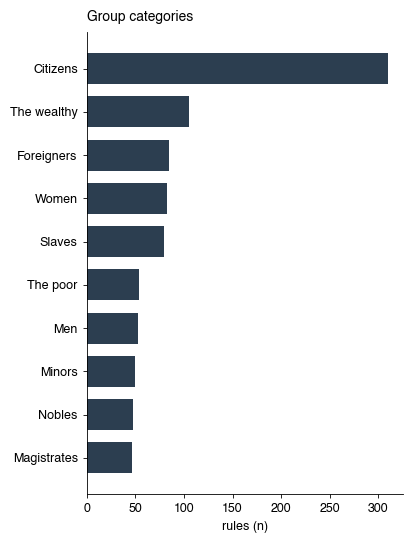

In [6]:
groups_exploded = (df['group_meta'].fillna('')
                                    .str.split(r'\s*;\s*')
                                    .explode()
                                    .str.strip())
top_groups = groups_exploded[groups_exploded != ''].value_counts().head(10)
print(top_groups)
minimal_hbar(top_groups, xlabel='rules (n)',
             title='Group categories', figsize=(4.2, 5.5));

### Figure 2: Criterion distribution (primary criterion per rule)

criterion
Citizenship            384
Wealth / Properties    170
Freedom                110
Occupation             108
Gender                  65
Lineage                 48
Age                     43
Nobility                34
Religion                21
Ethnicity               10
Health                   9
Education                5
Wealth                   2
Ethical Behavior         2
Name: count, dtype: int64


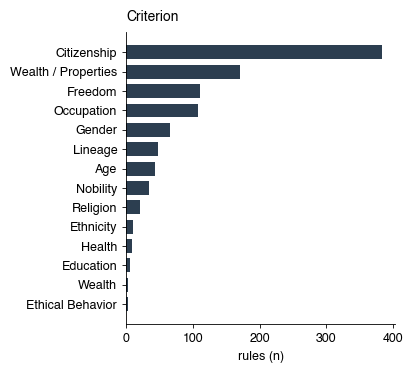

In [7]:
top_criteria = df['criterion'].value_counts()
print(top_criteria)
minimal_hbar(top_criteria, xlabel='rules (n)',
             title='Criterion', figsize=(4.2, 3.8));

### Figure 3: Top 20 resource categories

resource_meta
Eligibility for public office                 133
Political power                                77
Right to a legal trial                         62
Right to citizenship                           52
Right to retain property                       48
Protection from corporal punishment            45
Protection from enslavement                    38
Right to bodily autonomy                       34
Access to public honors                        33
Right to vote in the Ekklesia                  32
Protection from capital punishment             32
Exemption from compulsory public financing     30
Right to retain own earnings                   30
Access to religious rites                      29
Right to address the assembly                  27
Right to inherit property                      26
Right to remuneration for office               24
Right to reside in the city                    23
Protection from legal prosecution              22
Exemption from taxes                

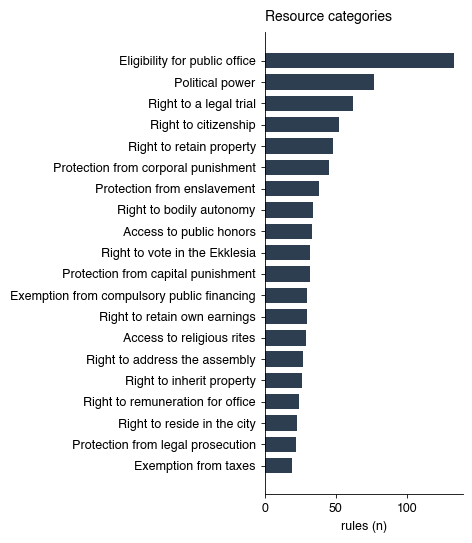

In [8]:
top_resources = df['resource_meta'].value_counts().head(20)
print(top_resources)
minimal_hbar(top_resources, xlabel='rules (n)',
             title='Resource categories', figsize=(4.8, 5.5));

### Figure 4: Resource type — 8 big meta-categories

From `prompt_resource_type_V1.md`, materiality-ordered. A rule can carry
more than one type (e.g. *Right to own land* = Material Wealth + Legal
Standing), so bars sum to more than 1 011.

resource_type
Political Power        368
Legal Standing         235
Bodily Autonomy        234
Material Wealth        229
Honor                   46
Religious Standing      36
Household Authority     24
Education               20
Name: count, dtype: int64


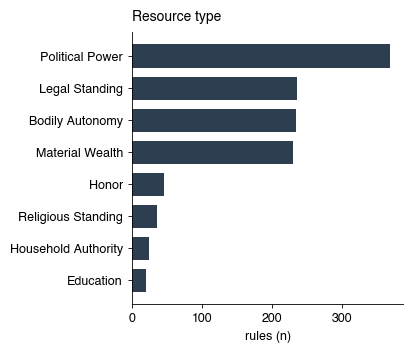

In [9]:
types = (df['resource_type'].fillna('')
                              .str.split(r'\s*;\s*')
                              .explode()
                              .str.strip())
type_counts = types[types != ''].value_counts().sort_values(ascending=False)
print(type_counts)
minimal_hbar(type_counts, xlabel='rules (n)',
             title='Resource type', figsize=(4.2, 3.6));

### Figure 5: Top 10 rules (as named by the core extractor)

rule
Citizen assembly voting                      13
Liturgy obligation for the wealthy           13
Slave testimony under torture                11
Noble access to magistracies                  3
Foreigner exclusion from land ownership       3
Dowry return upon divorce                     2
Wealth-based eligibility for magistracies     2
Wealth-based eligibility for high office      2
Citizen assembly attendance pay               2
Citizen right to bear arms                    2
Name: count, dtype: int64


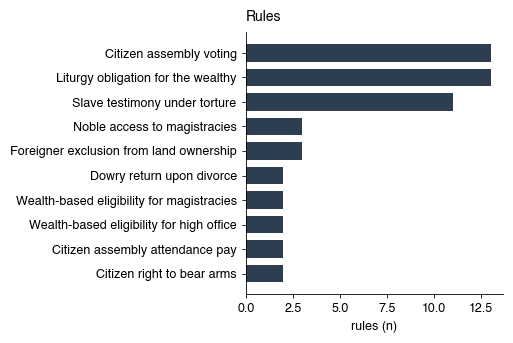

In [10]:
top_rules = df['rule'].value_counts().head(10)
print(top_rules)
minimal_hbar(top_rules, xlabel='rules (n)',
             title='Rules', figsize=(5.2, 3.5));